In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
df = pd.read_csv('diabetes.csv')
print(df.info())

In [303]:
print("\nVeri Setinin İstatistiki Özeti:")
display(df.describe())


Veri Setinin İstatistiki Özeti:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


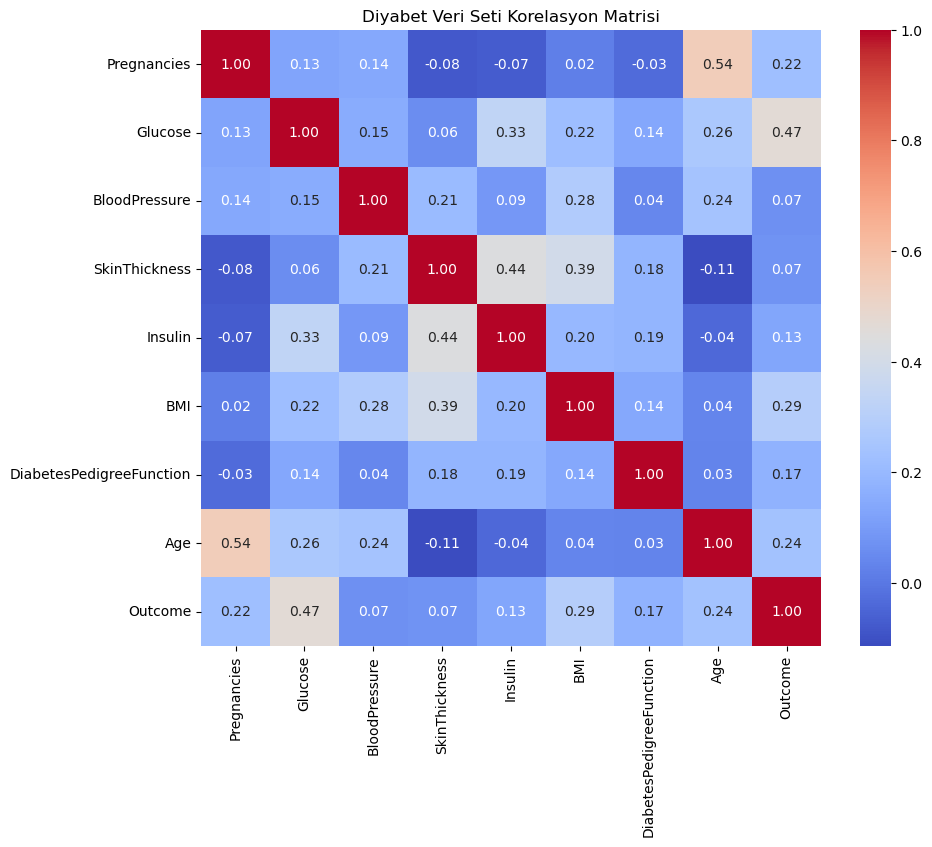

In [304]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Diyabet Veri Seti Korelasyon Matrisi')
plt.show()

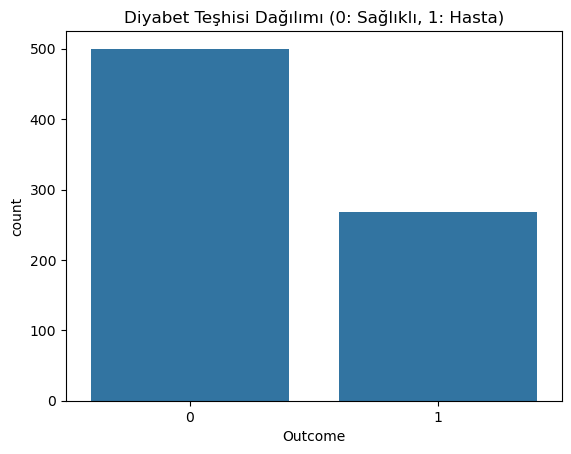

Outcome
0    500
1    268
Name: count, dtype: int64


In [305]:
sns.countplot(x='Outcome', data=df)
plt.title('Diyabet Teşhisi Dağılımı (0: Sağlıklı, 1: Hasta)')
plt.show()
print(df['Outcome'].value_counts())

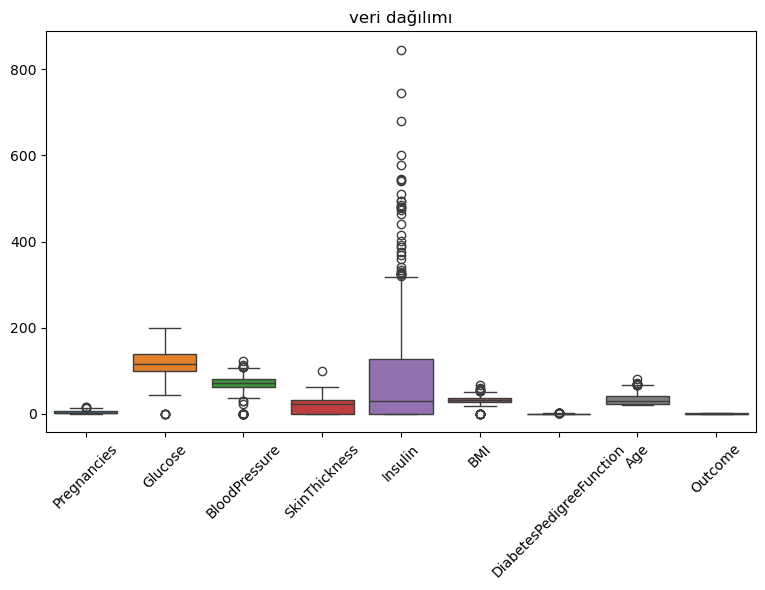

In [306]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=df)
plt.title('veri dağılımı')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [307]:
def remove_outliers_by_class(df, target_column):
    clean_df = pd.DataFrame()
    for label in df[target_column].unique():
        class_subset = df[df[target_column] == label]

        Q1 = class_subset.quantile(0.25)
        Q3 = class_subset.quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        filtered_subset = class_subset[~((class_subset < lower_bound) | (class_subset > upper_bound)).any(axis=1)]
        clean_df = pd.concat([clean_df, filtered_subset], axis=0)
    return clean_df

df = remove_outliers_by_class(df, 'Outcome')

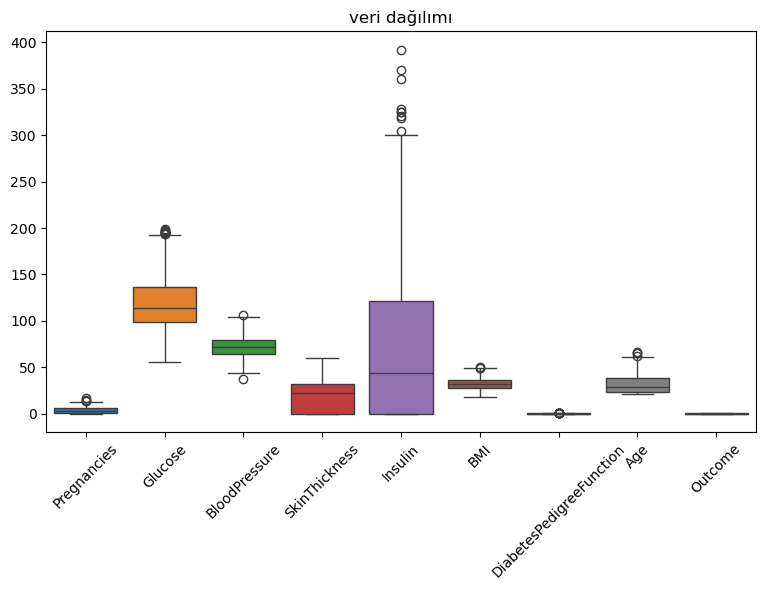

In [308]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=df)
plt.title('veri dağılımı')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [309]:
print("Eksik Veri Sayıları:")
print(df.isnull().sum())

print("\nToplam Eksik Değer Sayısı:", df.isnull().sum().sum())

Eksik Veri Sayıları:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Toplam Eksik Değer Sayısı: 0


In [310]:
cols_to_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print((df[cols_to_check] == 0).sum())

Glucose            0
BloodPressure      0
SkinThickness    167
Insulin          289
BMI                0
dtype: int64


In [311]:

df[cols] = df[cols].replace(0, np.nan)
df['Insulin'] = df['Insulin'].fillna(df.groupby('Outcome')['Insulin'].transform('median'))
df['SkinThickness'] = df['SkinThickness'].fillna(df.groupby('Outcome')['SkinThickness'].transform('median'))

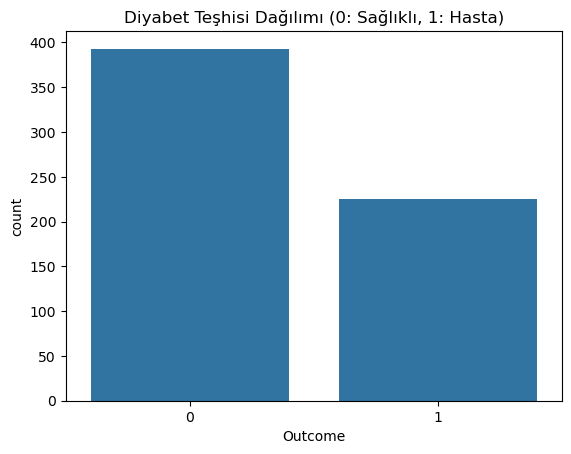

Outcome
0    393
1    225
Name: count, dtype: int64


In [312]:
sns.countplot(x='Outcome', data=df)
plt.title('Diyabet Teşhisi Dağılımı (0: Sağlıklı, 1: Hasta)')
plt.show()
print(df['Outcome'].value_counts())

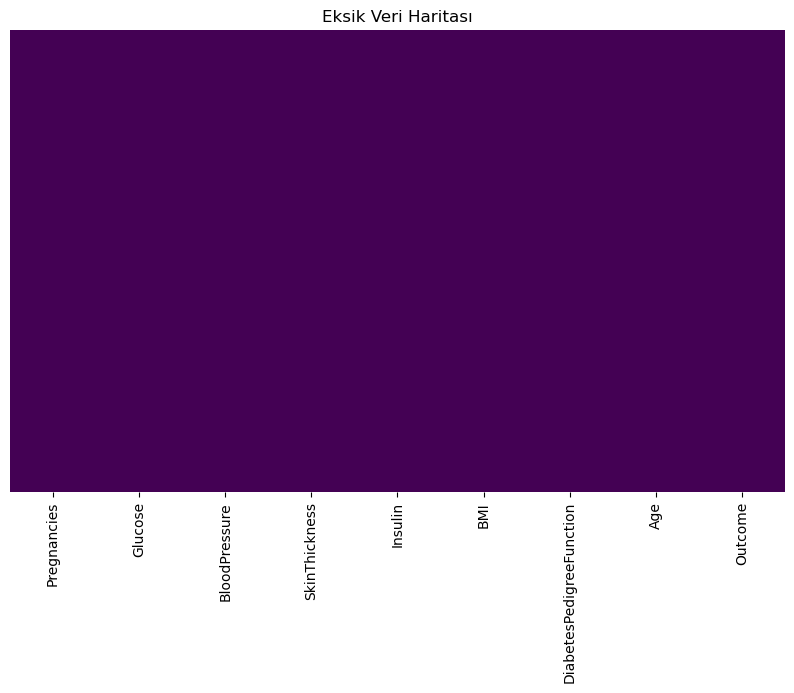

In [313]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Eksik Veri Haritası')
plt.show()

In [314]:

df_clean = df.drop(['BloodPressure', 'SkinThickness'], axis=1)
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_scaled, y)
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

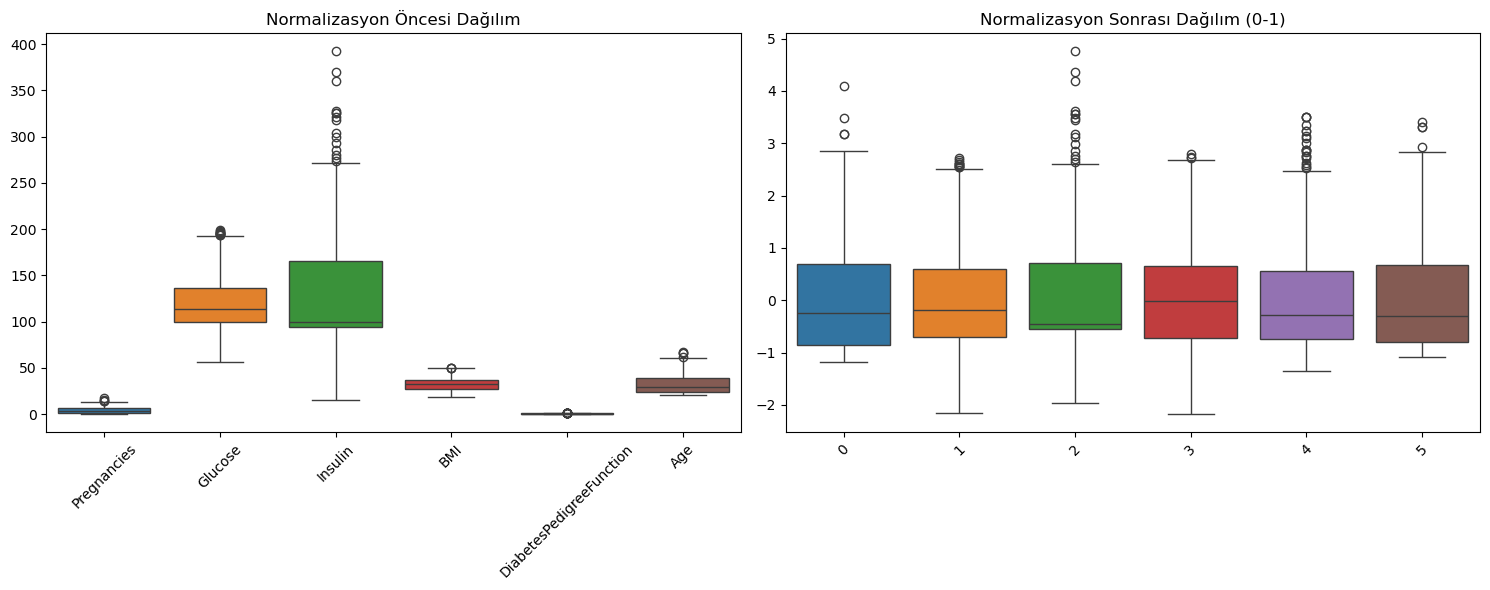

In [315]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=X)
plt.title('Normalizasyon Öncesi Dağılım')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(data=X_scaled)
plt.title('Normalizasyon Sonrası Dağılım (0-1)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [316]:
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5, weights='distance')

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print(f"Modelin Doğruluk (Accuracy) Skoru: %{accuracy_score(y_test, y_pred) * 100:.2f}")
print("\nKarmaşıklık Matrisi (Confusion Matrix):")
print(confusion_matrix(y_test, y_pred))
print("\nDetaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

Modelin Doğruluk (Accuracy) Skoru: %89.24

Karmaşıklık Matrisi (Confusion Matrix):
[[68 10]
 [ 7 73]]

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89        78
           1       0.88      0.91      0.90        80

    accuracy                           0.89       158
   macro avg       0.89      0.89      0.89       158
weighted avg       0.89      0.89      0.89       158



In [322]:
import os
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

checkpoint_path = "en_iyi_model.keras"

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

checkpoint = ModelCheckpoint(filepath=checkpoint_path,
                             monitor='val_accuracy',
                             mode='max',
                             save_best_only=True,
                             verbose=1)

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),

    Dense(16, activation='relu'),

    Dense(8, activation='relu'),

    Dense(4, activation='relu'),

    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("En iyi model takip edilecek")
history = model.fit(X_train, y_train,
                    epochs=200,
                    batch_size=16,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop, checkpoint],
                    verbose=1)
best_model = load_model(checkpoint_path)
loss, accuracy = best_model.evaluate(X_test, y_test)

print(f"\n--- EĞİTİM TAMAMLANDI ---")
print(f"Kaydedilen En İyi Modelin Test Doğruluğu: %{accuracy * 100:.2f}")git add .

En iyi model takip edilecek
Epoch 1/200


C:\Users\yigithan\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 1/40 ━━━━━━━━━━━━━━━━━━━━ 24s 629ms/step - accuracy: 0.4375 - loss: 0.7247
Epoch 1: val_accuracy improved from None to 0.82278, saving model to en_iyi_model.keras

Epoch 1: finished saving model to en_iyi_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5748 - loss: 0.6805 - val_accuracy: 0.8228 - val_loss: 0.6434
Epoch 2/200
 1/40 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6875 - loss: 0.6377
Epoch 2: val_accuracy improved from 0.82278 to 0.84177, saving model to en_iyi_model.keras

Epoch 2: finished saving model to en_iyi_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7452 - loss: 0.5974 - val_accuracy: 0.8418 - val_loss: 0.5353
Epoch 3/200
 1/40 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8125 - loss: 0.5153
Epoch 3: val_accuracy improved from 0.84177 to 0.84810, saving model to en_iyi_model.keras

Epoch 3: finished saving model to en_iyi_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7834 - loss: 0.4746 - val_accuracy: 0

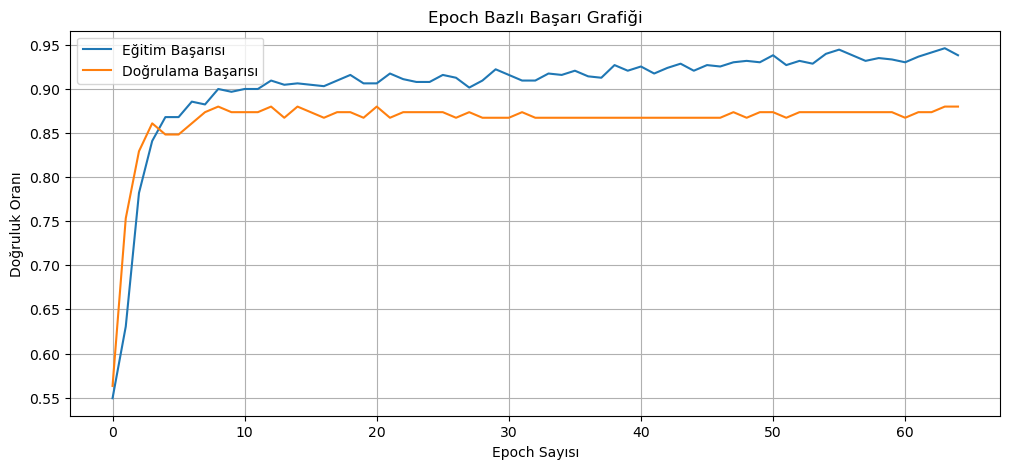

In [318]:
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Eğitim Başarısı')
plt.plot(history.history['val_accuracy'], label='Doğrulama Başarısı')
plt.title('Epoch Bazlı Başarı Grafiği')
plt.xlabel('Epoch Sayısı')
plt.ylabel('Doğruluk Oranı')
plt.legend()
plt.grid(True)
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


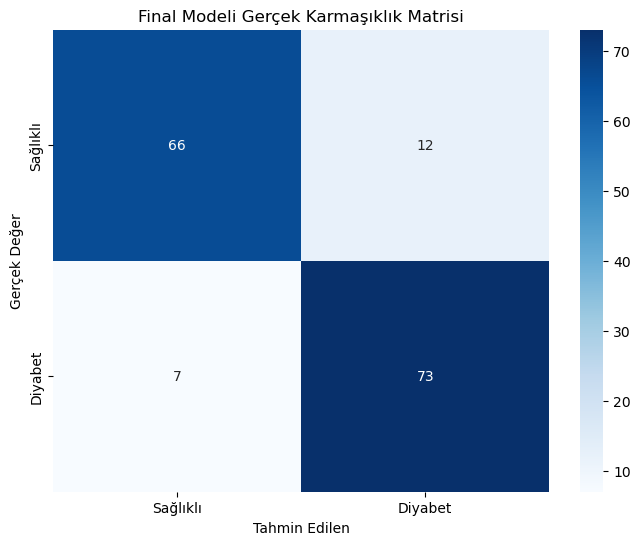

In [321]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_probs = best_model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sağlıklı', 'Diyabet'],
            yticklabels=['Sağlıklı', 'Diyabet'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Final Modeli Gerçek Karmaşıklık Matrisi')
plt.show()

In [320]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')

knn.fit(X_train, y_train)

knn_acc = accuracy_score(y_test, knn.predict(X_test))
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, svm.predict(X_test))


print(f"KNN Skoru: %{knn_acc*100:.2f}")
print(f"Random Forest Skoru: %{rf_acc*100:.2f}")
print(f"SVM Skoru: %{svm_acc*100:.2f}")

KNN Skoru: %89.24
Random Forest Skoru: %89.24
SVM Skoru: %87.97
